In [15]:
import pandas as pd
import yfinance as yf
import requests
from io import StringIO



import pandas as pd
import requests
from io import StringIO

def get_sp500_tickers():
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }
    
    response = requests.get(url, headers=headers)
    response.raise_for_status() 
    
    # Use the 'attrs' argument to specifically find the table with id="constituents"
    tables = pd.read_html(StringIO(response.text), attrs={'id': 'constituents'})
    
    # Because we searched by a unique ID, our target table will be the first and only item in the list
    df = tables[0]
    
    # Extract and clean the ticker symbols
    tickers = df['Symbol'].tolist()
    cleaned_tickers = [ticker.replace('.', '-') for ticker in tickers]
    
    return cleaned_tickers

# Test it out
tickers = get_sp500_tickers()
print(f"Successfully scraped {len(tickers)} tickers from the 'constituents' table.")

# sp500_tickers = pd.read_csv('SP500.csv')['Symbol'].tolist()
# print(f"Found {len(sp500_tickers)} tickers.")

# 2. Download the data
print("Downloading historical data from Yahoo Finance...")

data = yf.download(
    tickers = tickers,
    start = "2015-01-01", 
    end = "2025-01-01",
    group_by = 'ticker', 
    auto_adjust = True,  
    threads = True       
)

print("Download complete!")

Successfully scraped 503 tickers from the 'constituents' table.


[**********************45%                       ]  228 of 503 completed$Q: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1735707600")
[**********************82%**************         ]  411 of 503 completed$SNDK: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1735707600")
[*********************100%***********************]  503 of 503 completed

2 Failed downloads:
['Q', 'SNDK']: possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1735707600")


Download complete!


In [16]:
tickers

['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APP',
 'APTV',
 'ACGL',
 'ADM',
 'ARES',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AZO',
 'AVB',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BRK-B',
 'BBY',
 'TECH',
 'BIIB',
 'BLK',
 'BX',
 'XYZ',
 'BK',
 'BA',
 'BKNG',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BF-B',
 'BLDR',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CPT',
 'CPB',
 'COF',
 'CAH',
 'CCL',
 'CARR',
 'CVNA',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CIEN',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COIN',
 'CL',
 'CMCSA',
 'FIX',
 'CAG',
 'CO

In [17]:
data.to_csv('sp500_data.csv')

In [11]:
data 

Ticker     ARNC                                  MON                 ...  \
Price      Open High Low Close Adj Close Volume Open High Low Close  ...   
Date                                                                 ...   
2015-01-02  NaN  NaN NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN  ...   
2015-01-05  NaN  NaN NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN  ...   
2015-01-06  NaN  NaN NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN  ...   
2015-01-07  NaN  NaN NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN  ...   
2015-01-08  NaN  NaN NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN  ...   
...         ...  ...  ..   ...       ...    ...  ...  ...  ..   ...  ...   
2024-12-24  NaN  NaN NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN  ...   
2024-12-26  NaN  NaN NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN  ...   
2024-12-27  NaN  NaN NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN  ...   
2024-12-30  NaN  NaN NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN  ...   
2024-12-31  NaN  NaN NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN  ...   

Ticker             VLO                                               \
Price             Open        High         Low       Close   Volume   
Date                                                                  
2015-01-02   32.115319   32.705126   31.804212   32.627350  5897000   
2015-01-05   32.303283   32.303283   31.169038   31.285704  7732700   
2015-01-06   31.253288   31.726429   30.650518   30.903292  8586800   
2015-01-07   31.156072   31.726435   30.566265   30.663486  8825800   
2015-01-08   31.169028   32.484750   30.955141   32.419937  8941700   
...                ...         ...         ...         ...      ...   
2024-12-24  113.692034  115.243388  112.795911  114.511070  1170100   
2024-12-26  114.665258  115.561381  113.316253  115.320488  1884400   
2024-12-27  115.166309  116.505683  113.788399  115.224129  1697800   
2024-12-30  115.455390  116.727307  113.701686  115.233765  2890200   
2024-12-31  115.484284  118.509904  115.147035  118.124474  2689900   

Ticker             TXN                                               
Price             Open        High         Low       Close   Volume  
Date                                                                 
2015-01-02   39.360214   39.742352   38.956027   39.301422  4020100  
2015-01-05   39.088316   39.308783   38.654736   38.691483  5599300  
2015-01-06   38.867838   38.963373   38.008029   38.052120  5468400  
2015-01-07   38.221156   38.853154   38.059484   38.735573  4577100  
2015-01-08   39.044230   39.646832   38.956042   39.367577  6295200  
...                ...         ...         ...         ...      ...  
2024-12-24  183.303380  185.208677  183.284131  185.179810  1950900  
2024-12-26  183.418856  185.449253  183.332255  184.496597  2019000  
2024-12-27  183.255289  184.544731  182.533584  183.967361  3253500  
2024-12-30  182.533564  182.533564  180.147131  180.868835  4065200  
2024-12-31  181.542414  181.965816  179.040498  180.435791  3050500  

[2516 rows x 2610 columns]

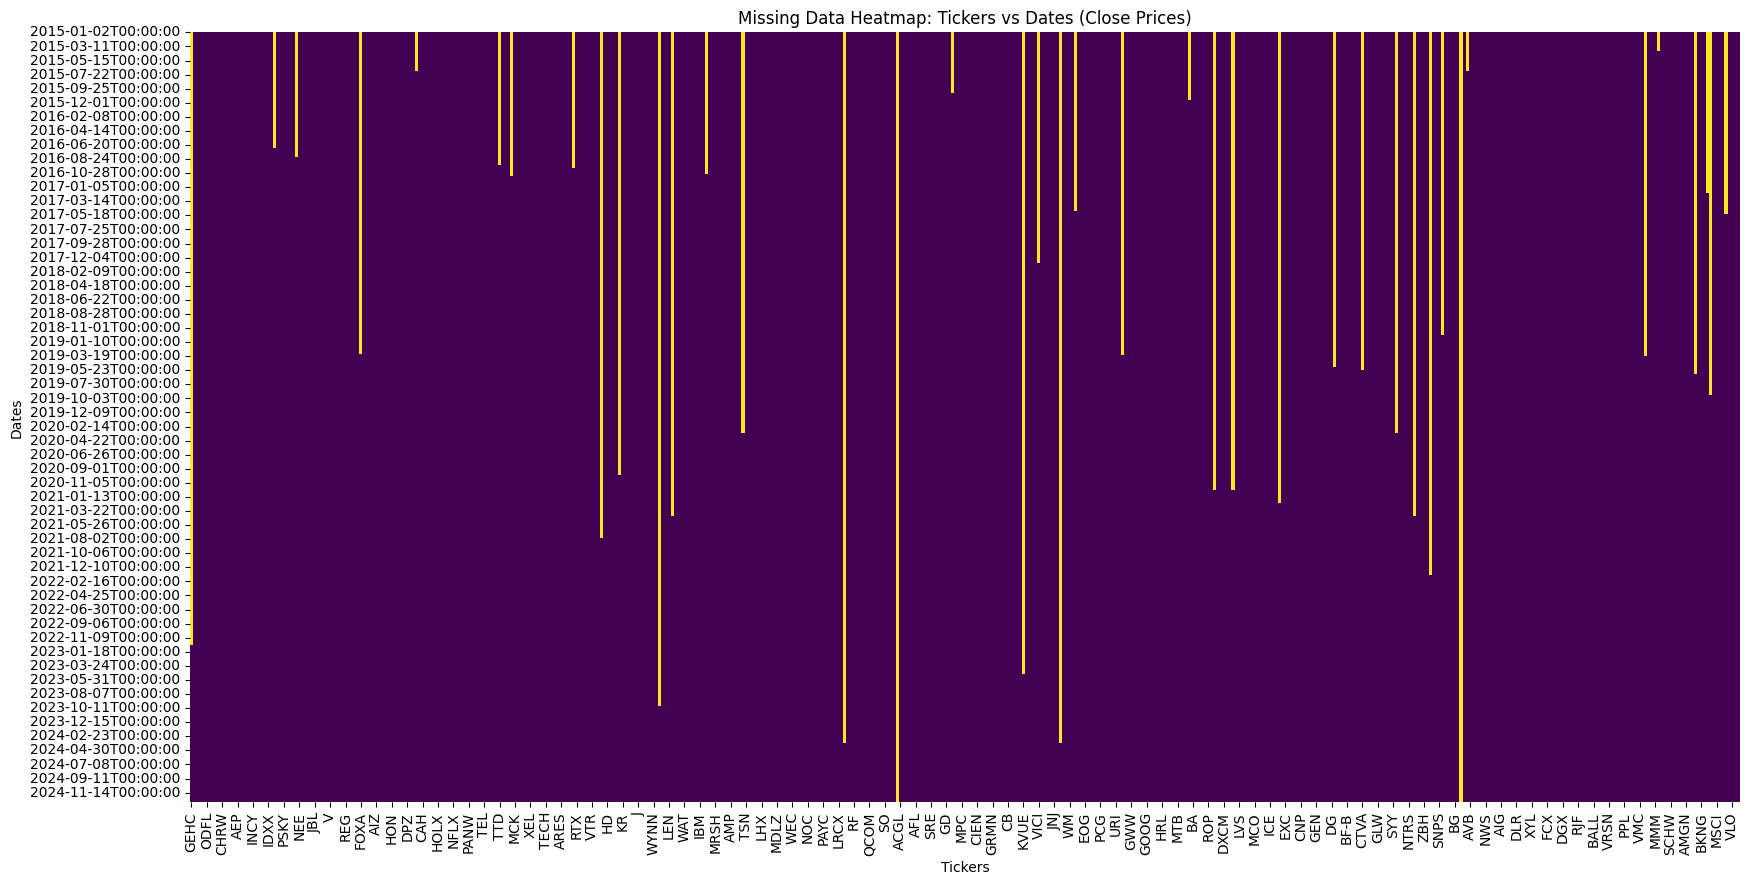

In [18]:
import seaborn as sns

import matplotlib.pyplot as plt

# Select 'Close' prices for all tickers
close_data = data.xs('Close', level=1, axis=1)

# Create a heatmap of missing data (True for missing, False for present)
plt.figure(figsize=(20, 10))
sns.heatmap(close_data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap: Tickers vs Dates (Close Prices)')
plt.xlabel('Tickers')
plt.ylabel('Dates')
plt.show()

In [20]:
close_data_dropna = close_data.dropna(axis=1, how='all')

In [22]:
close_data_dropna

Ticker,GEHC,INTU,IVZ,IRM,A,ODFL,YUM,HIG,CMCSA,SPG,...,DDOG,BR,MSCI,BLK,DECK,IR,CSGP,VLO,TXN,TTWO
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,NaN,83.238876,23.924995,20.735733,37.054718,24.805017,42.024673,32.980530,20.616899,106.563278,...,NaN,37.381256,42.064548,269.715454,14.956667,NaN,18.013000,32.627338,39.301434,28.100000
2015-01-05,NaN,82.910370,23.228148,20.836853,36.360394,24.174576,41.170826,32.286030,20.196442,107.000214,...,NaN,36.823818,41.667618,262.736786,14.843333,NaN,17.655001,31.285686,38.691483,27.620001
2015-01-06,NaN,80.364182,22.745249,21.028454,35.793987,23.720142,40.665497,31.757275,19.932985,109.978531,...,NaN,37.102524,42.876015,258.653992,14.585000,NaN,17.583000,30.903294,38.052139,27.930000
2015-01-07,NaN,81.151260,23.044769,21.060392,36.269047,23.592133,42.013069,32.057175,19.914938,112.002426,...,NaN,37.709156,43.855083,264.128113,15.058333,NaN,17.677000,30.663479,38.735577,28.100000
2015-01-08,NaN,82.240356,23.448210,21.448915,37.356194,24.212980,42.744961,32.404415,20.348024,111.841393,...,NaN,38.274799,45.178143,267.212830,15.668333,NaN,18.004000,32.419949,39.367565,28.459999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,79.182579,639.875610,16.861687,101.080406,134.764069,180.021179,131.828506,108.270653,34.276783,163.101990,...,148.399994,222.575287,597.933105,1027.918823,208.009995,92.238380,72.949997,114.511078,185.179825,185.389999
2024-12-26,79.531792,640.768127,16.975683,101.224014,134.496704,179.892288,132.804993,108.672127,34.142887,163.525391,...,147.559998,222.966873,600.942810,1027.382935,209.429993,92.168457,73.099998,115.320480,184.496613,187.160004
2024-12-27,79.332245,633.212036,16.795191,100.257050,134.209549,178.692581,132.053116,107.820213,33.857250,161.841202,...,145.990005,221.625580,599.585571,1017.540771,207.110001,91.459312,72.220001,115.224136,183.967346,186.429993


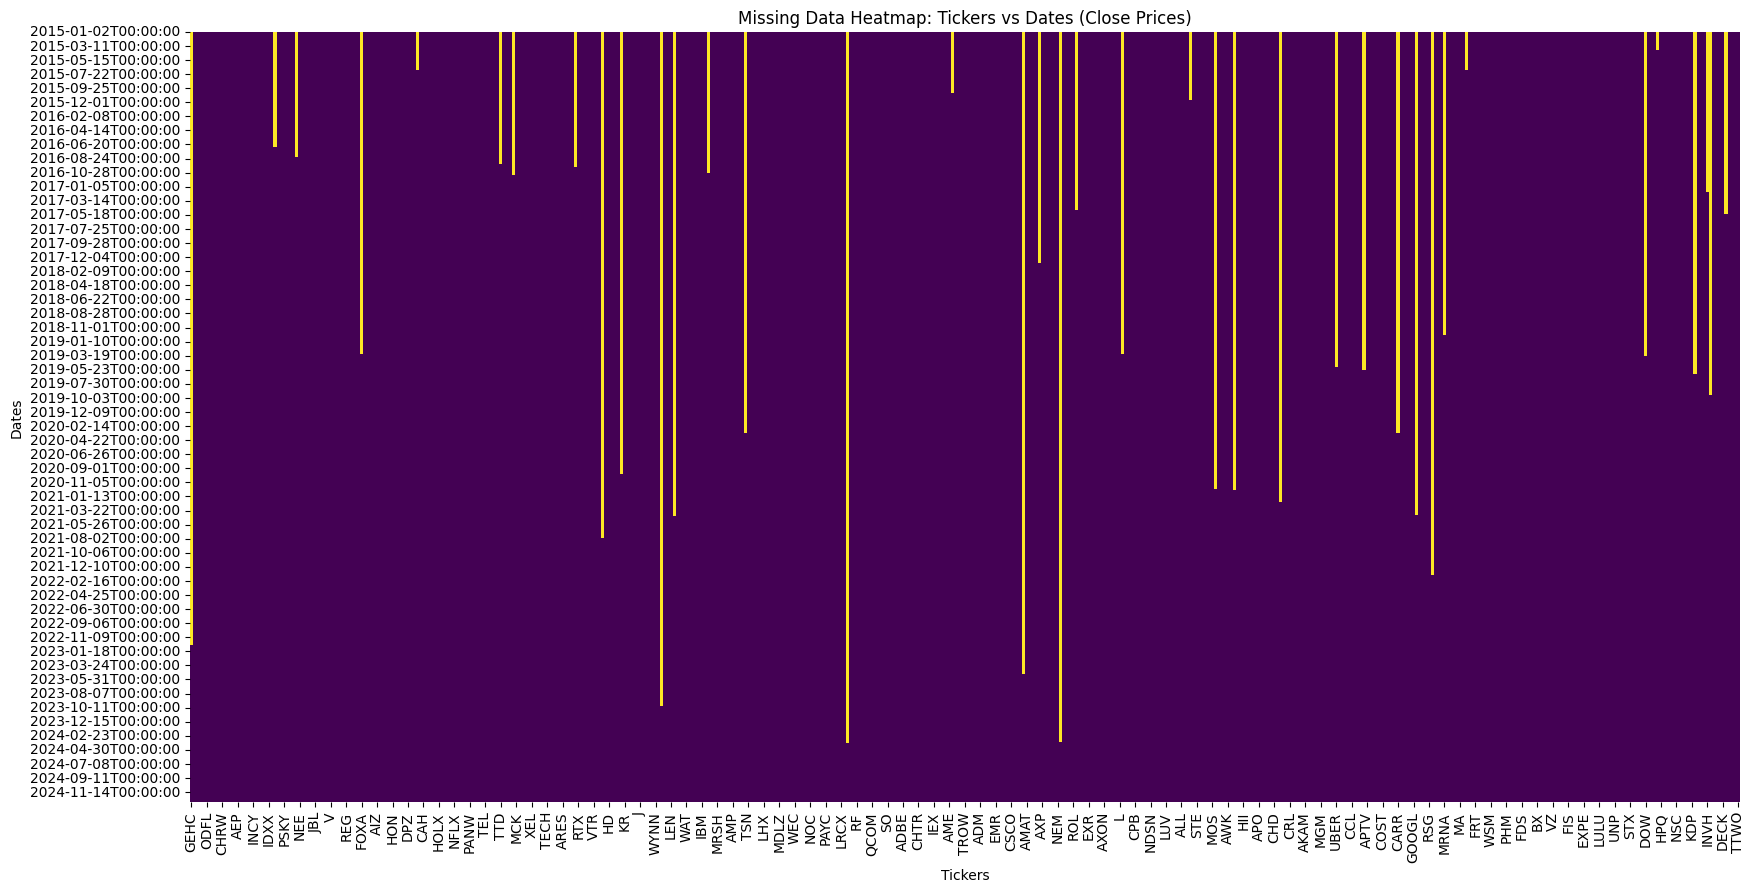

In [21]:
import seaborn as sns

import matplotlib.pyplot as plt
# Create a heatmap of missing data (True for missing, False for present)
plt.figure(figsize=(20, 10))
sns.heatmap(close_data_dropna.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap: Tickers vs Dates (Close Prices)')
plt.xlabel('Tickers')
plt.ylabel('Dates')
plt.show()